In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problem_solver.encoder_decoder.deformed_anisotropic_gaussian.unrolled.gradient_descent import GradientDescentUnrolledSolver
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.nn.module.polynomial_activation import PolynomialActivation
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.polynomial_parity import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

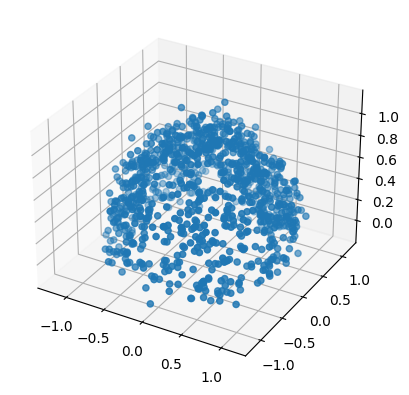

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_train_clean = uniform_sphere_sampling(3, num_samples)
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x
    
    def adjoint_forward(self, x):
        return x

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for _ in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=True))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=True))
        transforms_list.append(PolynomialParityTransform(dim, order, parity=1))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=True))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=True))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Create the feed forward model
def create_feed_forward_model(in_dim, out_dim, n_layers, hidden_dim=16):
    layers = []
    layers.append(nn.Linear(in_dim, hidden_dim))
    layers.append(nn.ReLU())
    for _ in range(n_layers - 2):
        layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(hidden_dim, out_dim))
    
    return nn.Sequential(*layers)


In [6]:
# Initialize the model
forward = IdentityForward()

dim = 3
n_flows = 4
flow = create_flow_model(dim, n_flows, 2)
phi = NFlowVectorDiffeomorphism(dim, flow)

l2_weight = 0.
num_steps = 8

n_layers = 4
Gamma = create_feed_forward_model(2 * dim, dim, n_layers)

model = GradientDescentUnrolledSolver(forward, phi, l2_weight, num_steps, Gamma).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [7]:
# Training loop
def train(model, train_loader, optimizer, n_epochs):
    for epoch in range(n_epochs):
        for _, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")
        print(model.psi.diagonal)
        print(model.phi.inverse(torch.zeros(3)[None]))

In [8]:
# Train the model
n_epochs = 100
train(model, train_loader, optimizer, n_epochs)

Epoch 1/100, Loss: 33.3880
tensor([1.0000, 1.0000, 1.0000], grad_fn=<WhereBackward0>)
tensor([[ 0.0040, -0.0199,  0.0039]], grad_fn=<MmBackward0>)
Epoch 2/100, Loss: 27.0720
tensor([1.0000, 1.0000, 1.0000], grad_fn=<WhereBackward0>)
tensor([[ 0.0078, -0.0393,  0.0075]], grad_fn=<MmBackward0>)
Epoch 3/100, Loss: 22.0584
tensor([1.0000, 1.0000, 1.0000], grad_fn=<WhereBackward0>)
tensor([[ 0.0115, -0.0579,  0.0105]], grad_fn=<MmBackward0>)
Epoch 4/100, Loss: 18.0673
tensor([1.0000, 1.0000, 1.0000], grad_fn=<WhereBackward0>)
tensor([[ 0.0151, -0.0756,  0.0128]], grad_fn=<MmBackward0>)
Epoch 5/100, Loss: 14.8908
tensor([1.0000, 1.0000, 1.0000], grad_fn=<WhereBackward0>)
tensor([[ 0.0184, -0.0923,  0.0145]], grad_fn=<MmBackward0>)
Epoch 6/100, Loss: 12.3948
tensor([1.0000, 1.0000, 1.0000], grad_fn=<WhereBackward0>)
tensor([[ 0.0216, -0.1078,  0.0159]], grad_fn=<MmBackward0>)
Epoch 7/100, Loss: 10.4952
tensor([1.0000, 1.0000, 1.0000], grad_fn=<WhereBackward0>)
tensor([[ 0.0246, -0.1222,  0.01

In [9]:
rec_data_train = model.decode_to_data(model.encode(data_train)).detach().numpy()
print(rec_data_train[0:10])

[[-0.0700926  -0.3767317   0.64003277]
 [-0.07515163 -0.31183198  0.6340308 ]
 [-0.06405199 -0.2866189   0.6210795 ]
 [ 0.06814345 -0.20196033  0.49337685]
 [-0.1332191   0.49842378  0.5245224 ]
 [-0.06196516  0.32432023  0.5006357 ]
 [-0.17430393  0.9214026   0.44624633]
 [ 0.05108736 -0.39435127  0.53970855]
 [-0.17582044 -0.40035313  0.6901295 ]
 [-0.15213363  0.81466204  0.47208998]]


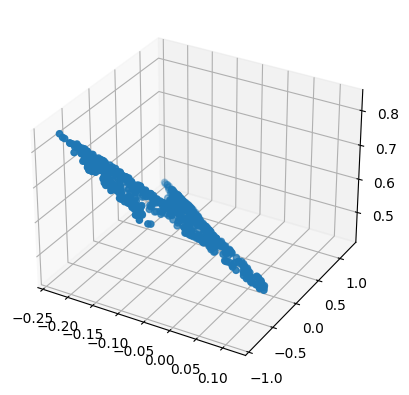

In [10]:
ax = plt.axes(projection='3d')
# ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(rec_data_train[:,0], rec_data_train[:,1], rec_data_train[:,2])
plt.show()

### Evaluating Geometry ###

In [11]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

In [12]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([0.,-1.,0.]).to(device)

In [13]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

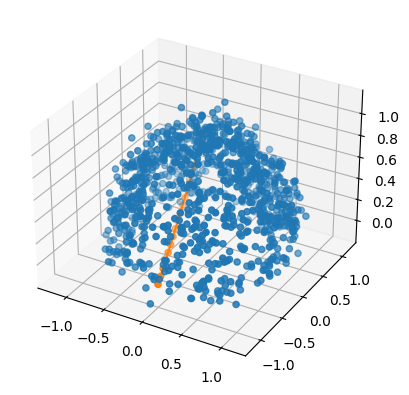

In [14]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [15]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)
print(data_train.mean(0))

tensor([0.0326, 0.0332, 0.4824], grad_fn=<SelectBackward0>)
tensor([0.0321, 0.0136, 0.4825])


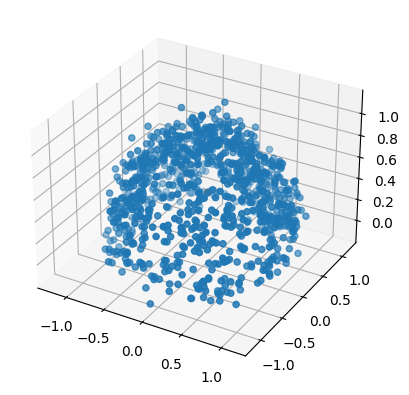

In [16]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [17]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [18]:
# compute low rank approximations
l2_pga_solver.solve(2) # compute rank 2 approximation

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


In [19]:
# compute approximations
approximations = l2_pga_solver.exp_x_Xi[2]

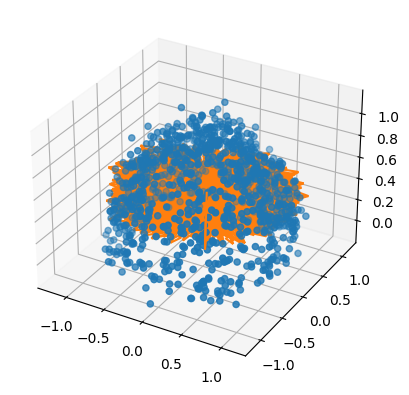

In [20]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 0], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 1], l2_pga_solver.Xi[2].detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


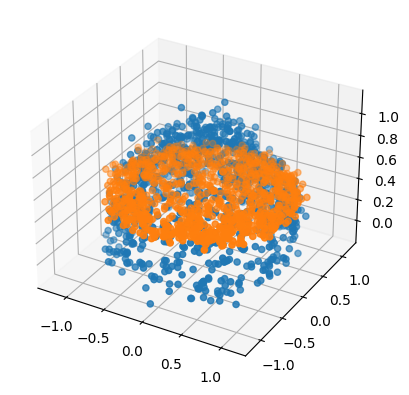

In [21]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [22]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0914, grad_fn=<SumBackward0>)
